In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import GroupKFold
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

In [3]:
feature_matrix = pd.read_csv(
    r"C:\Users\cbala\OneDrive\Desktop\RecruitSmart\flattened_feature_matrix.csv"
)

feature_matrix.head()

,application_id,job_id,title,required_experience,person_id,name,total_skills,match_relevance_score
0,1,15796,Beauty & Fragrance consultants needed,NaN,20608,MySQL Database Administrator,19,0.5
1,2,861,Retail Territory Merchandiser,NaN,37600,MSSQL/MYSQL/PostgreSQL Database Administrator,113,0.9
2,3,5391,Inside Sales Rep,Associate,51921,Shmitt Technologies,66,0.9
3,4,11965,Cities Project Manager,NaN,28530,VP of Information Technology,26,0.5
4,5,11285,Digital Procurement Assistant,Entry level,35955,Python Developer,58,0.9


In [5]:
feature_matrix = pd.read_csv(
    r"C:\Users\cbala\OneDrive\Desktop\RecruitSmart\final_feature_set.csv"
)

In [7]:
print(feature_matrix.columns)

Index(['job_id', 'person_id', 'title', 'required_experience', 'total_skills',
       'match_relevance_score'],
      dtype='object')


In [9]:
X = feature_matrix[["total_skills"]]

y = feature_matrix["match_relevance_score"]

groups = feature_matrix["job_id"]

In [11]:
gkf = GroupKFold(n_splits=5)

In [13]:
mae_scores = []

for train_idx, test_idx in gkf.split(X, y, groups):

    X_train = X.iloc[train_idx]
    X_test = X.iloc[test_idx]

    y_train = y.iloc[train_idx]
    y_test = y.iloc[test_idx]

    model = RandomForestRegressor(
        n_estimators=100,
        random_state=42
    )

    model.fit(X_train, y_train)

    predictions = model.predict(X_test)

    mae = mean_absolute_error(y_test, predictions)

    mae_scores.append(mae)

In [15]:
print("MAE Scores")

print(mae_scores)

print()

print("Average MAE")

print(np.mean(mae_scores))

MAE Scores
[8.493206138382448e-16, 8.348877145181177e-16, 8.770761894538737e-16, 7.810418978237976e-16, 9.137135492665039e-16]

Average MAE
8.512079929801075e-16


In [17]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance

,Feature,Importance
0,total_skills,1.0


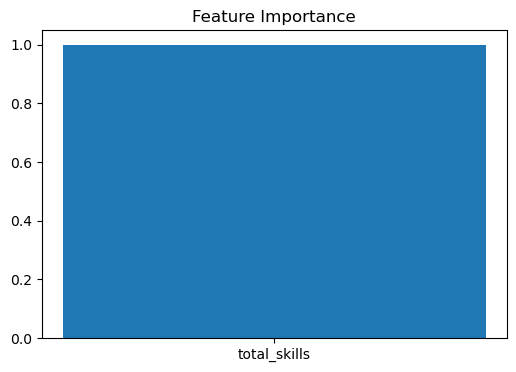

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

plt.bar(
    importance["Feature"],
    importance["Importance"]
)

plt.title("Feature Importance")

plt.show()